In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
import os
print(os.getcwd())

c:\Users\hassa\OneDrive\Documents\Projects\housing-market-analysis


In [3]:
df = pd.read_csv("18100205.csv", usecols=["REF_DATE", "GEO", "New housing price indexes", "VALUE"])
print(df.shape)
print(df.head())

(64920, 4)
  REF_DATE              GEO New housing price indexes  VALUE
0  1981-01           Canada    Total (house and land)   38.2
1  1981-01           Canada                House only   36.1
2  1981-01           Canada                 Land only   40.6
3  1981-01  Atlantic Region    Total (house and land)    NaN
4  1981-01  Atlantic Region                House only    NaN


In [4]:
print(df["GEO"].unique())

<StringArray>
[                                             'Canada',
                                     'Atlantic Region',
                           'Newfoundland and Labrador',
               'St. John's, Newfoundland and Labrador',
                                'Prince Edward Island',
                 'Charlottetown, Prince Edward Island',
                                         'Nova Scotia',
                                'Halifax, Nova Scotia',
                                       'New Brunswick',
 'Saint John, Fredericton, and Moncton, New Brunswick',
                                              'Quebec',
                                      'Québec, Quebec',
                                  'Sherbrooke, Quebec',
                              'Trois-Rivières, Quebec',
                                    'Montréal, Quebec',
        'Ottawa-Gatineau, Quebec part, Ontario/Quebec',
                                             'Ontario',
       'Ottawa-Gatineau, Ontario p

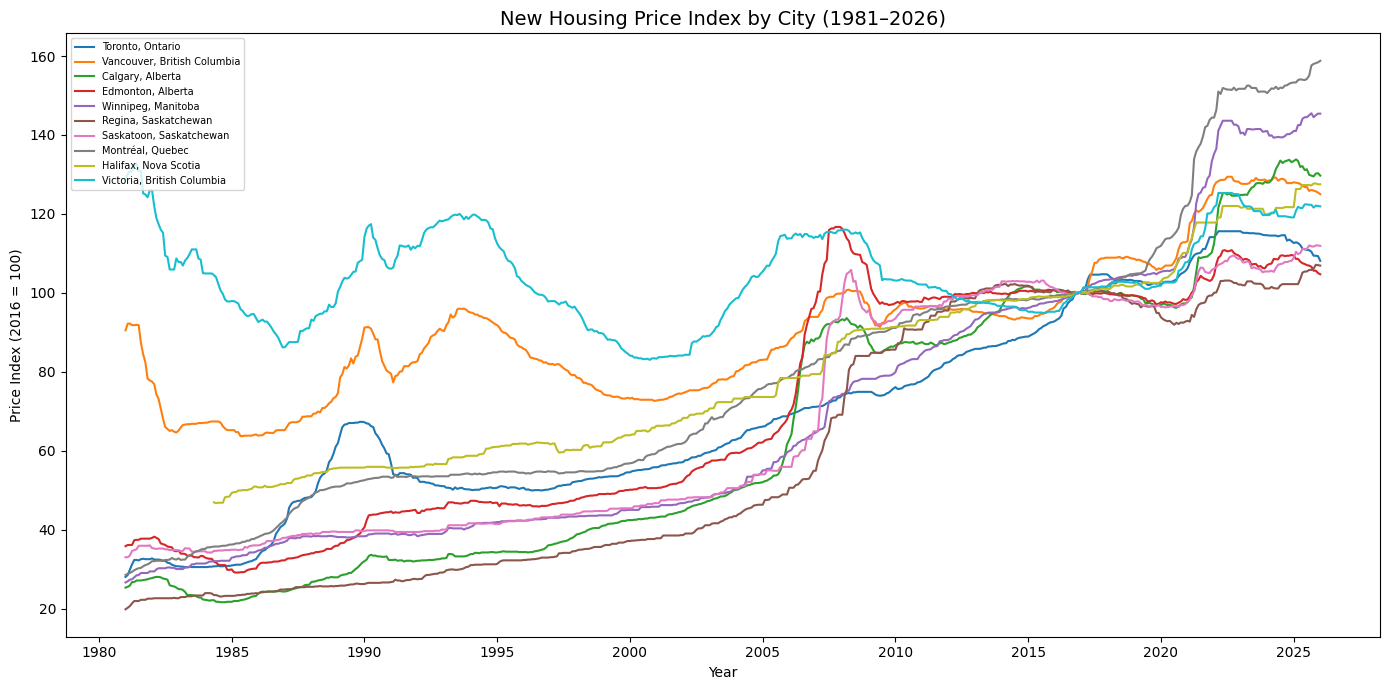

In [5]:
cities = [
    "Toronto, Ontario",
    "Vancouver, British Columbia",
    "Calgary, Alberta",
    "Edmonton, Alberta",
    "Winnipeg, Manitoba",
    "Regina, Saskatchewan",
    "Saskatoon, Saskatchewan",
    "Montréal, Quebec",
    "Halifax, Nova Scotia",
    "Victoria, British Columbia"
]

df_cities = df[df["GEO"].isin(cities)]
df_cities = df_cities[df_cities["New housing price indexes"] == "Total (house and land)"]
df_cities["REF_DATE"] = pd.to_datetime(df_cities["REF_DATE"])

plt.figure(figsize=(14, 7))

for city in cities:
    city_data = df_cities[df_cities["GEO"] == city]
    plt.plot(city_data["REF_DATE"], city_data["VALUE"], label=city)

plt.title("New Housing Price Index by City (1981–2026)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Price Index (2016 = 100)")
plt.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.savefig("housing_price_trends.png", dpi=150)
plt.show()

## 📈 Long-Term Housing Price Trends by City (1981–2026)

The chart above plots the New Housing Price Index across 10 major Canadian 
cities over 45 years. A few patterns stand out immediately:

- Prices were relatively flat and stable from 1981 through the early 2000s
- A gradual upward trend began around 2002–2005 across most markets
- The most dramatic acceleration occurred post-2020, with nearly all cities 
  seeing sharp increases during the pandemic period
- Vancouver and Calgary show notable volatility, reflecting their sensitivity 
  to commodity cycles and immigration-driven demand

In [6]:
conn = sqlite3.connect("housing.db")
df_cities.to_sql("housing", conn, if_exists="replace", index=False)
print("Data loaded into SQLite database")

Data loaded into SQLite database


In [7]:
query = """
SELECT 
    GEO,
    REF_DATE,
    MAX(VALUE) as peak_index
FROM housing
GROUP BY GEO
ORDER BY peak_index DESC
"""

peak_prices = pd.read_sql_query(query, conn)
print(peak_prices)

                           GEO             REF_DATE  peak_index
0             Montréal, Quebec  2026-01-01 00:00:00       158.8
1           Winnipeg, Manitoba  2025-09-01 00:00:00       145.5
2             Calgary, Alberta  2025-02-01 00:00:00       133.8
3   Victoria, British Columbia  1981-06-01 00:00:00       132.8
4  Vancouver, British Columbia  2022-07-01 00:00:00       129.4
5         Halifax, Nova Scotia  2025-10-01 00:00:00       127.7
6            Edmonton, Alberta  2007-10-01 00:00:00       116.7
7             Toronto, Ontario  2022-03-01 00:00:00       115.6
8      Saskatoon, Saskatchewan  2025-08-01 00:00:00       112.0
9         Regina, Saskatchewan  2025-11-01 00:00:00       107.1


In [8]:
query2 = """
SELECT 
    GEO,
    ROUND(AVG(CASE WHEN REF_DATE LIKE '2015%' THEN VALUE END), 2) as avg_2015,
    ROUND(AVG(CASE WHEN REF_DATE LIKE '2024%' THEN VALUE END), 2) as avg_2024,
    ROUND(
        (AVG(CASE WHEN REF_DATE LIKE '2024%' THEN VALUE END) - 
         AVG(CASE WHEN REF_DATE LIKE '2015%' THEN VALUE END)) /
         AVG(CASE WHEN REF_DATE LIKE '2015%' THEN VALUE END) * 100
    , 2) as pct_growth
FROM housing
GROUP BY GEO
ORDER BY pct_growth DESC
"""

growth = pd.read_sql_query(query2, conn)
print(growth)

                           GEO  avg_2015  avg_2024  pct_growth
0             Montréal, Quebec     98.62    152.03       54.16
1           Winnipeg, Manitoba     97.08    139.86       44.07
2  Vancouver, British Columbia     94.56    128.48       35.88
3             Calgary, Alberta    100.88    131.50       30.36
4   Victoria, British Columbia     95.08    119.68       25.87
5             Toronto, Ontario     90.85    114.20       25.70
6         Halifax, Nova Scotia     98.90    121.09       22.44
7            Edmonton, Alberta    100.49    108.66        8.13
8      Saskatoon, Saskatchewan    102.49    106.79        4.20
9         Regina, Saskatchewan    100.58    101.67        1.08


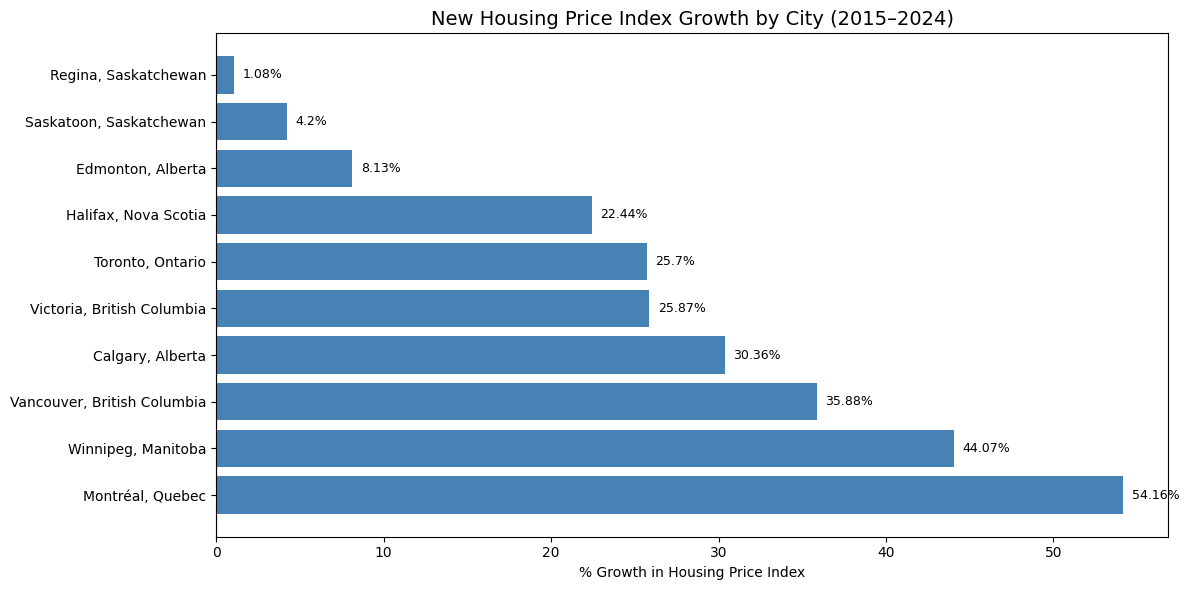

Chart saved


In [9]:
plt.figure(figsize=(12, 6))
bars = plt.barh(growth["GEO"], growth["pct_growth"], color="steelblue")
plt.xlabel("% Growth in Housing Price Index")
plt.title("New Housing Price Index Growth by City (2015–2024)", fontsize=14)
plt.axvline(x=0, color="black", linewidth=0.8)

for bar, val in zip(bars, growth["pct_growth"]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f"{val}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("growth_by_city.png", dpi=150)
plt.show()

print("Chart saved")

## 🏙️ Which Cities Grew the Most? (2015–2024)

Looking at the 2015–2024 window specifically, Montréal leads all markets 
with 54.16% growth in the housing price index, followed by Winnipeg at 
44.07%. This is notable because these cities were historically considered 
more affordable alternatives to Toronto and Vancouver.

Toronto, often perceived as Canada's hottest market, grew 25.7% over this 
period — significant, but well below Montréal and Winnipeg. Regina and 
Saskatoon saw the least growth, reflecting slower population and economic 
expansion in those markets.

**Key insight:** Affordability-driven migration appears to have shifted 
demand toward historically cheaper markets, compressing the price gap 
between major and secondary cities.

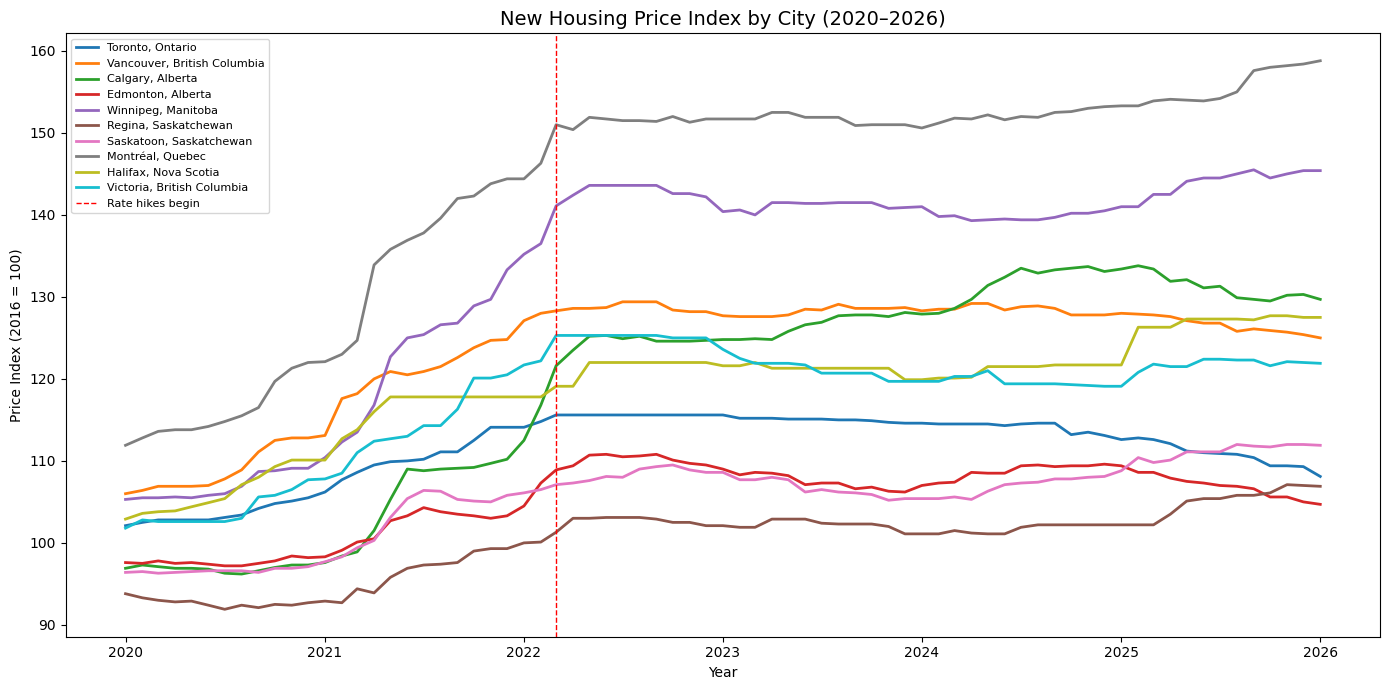

Chart saved


In [10]:
df_2020 = df_cities[df_cities["REF_DATE"] >= "2020-01-01"]

plt.figure(figsize=(14, 7))

for city in cities:
    city_data = df_2020[df_2020["GEO"] == city]
    plt.plot(city_data["REF_DATE"], city_data["VALUE"], label=city, linewidth=2)

plt.title("New Housing Price Index by City (2020–2026)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Price Index (2016 = 100)")
plt.axvline(pd.Timestamp("2022-03-01"), color="red", linestyle="--", linewidth=1, label="Rate hikes begin")
plt.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("post2020_trends.png", dpi=150)
plt.show()

print("Chart saved")

## 🏦 The Pandemic Surge and Rate Hike Impact (2020–2026)

This chart isolates the most turbulent period in recent Canadian housing 
history. Two distinct phases are visible:

**Phase 1 — Pandemic Surge (2020–2022):** All cities experienced sharp 
price acceleration driven by record-low interest rates, increased savings, 
and shifting housing preferences during COVID-19 lockdowns.

**Phase 2 — Rate Hike Cooling (March 2022 onwards):** The Bank of Canada 
began its most aggressive rate hike cycle in decades starting March 2022. 
The effect is visible across all markets — price growth slowed, and several 
cities saw modest corrections. This demonstrates how directly sensitive 
Canadian housing markets are to monetary policy decisions.

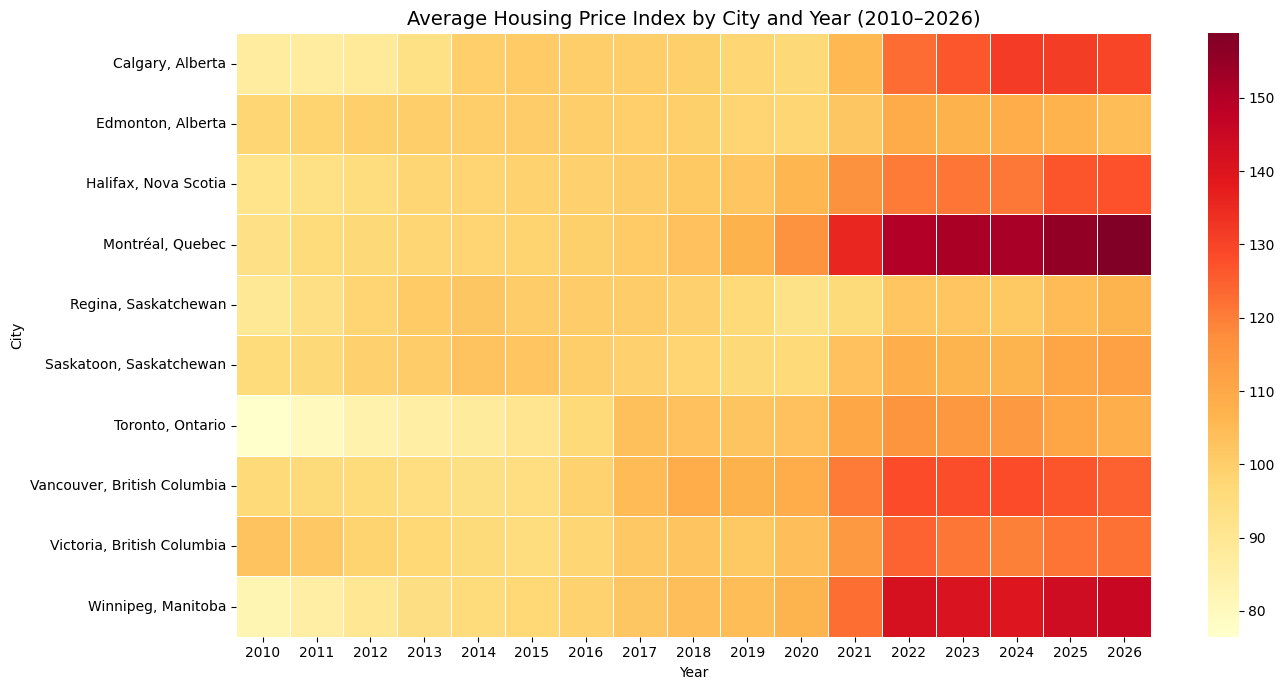

Chart saved


In [11]:
df_cities["Year"] = df_cities["REF_DATE"].dt.year

heatmap_data = df_cities[df_cities["Year"] >= 2010].groupby(["GEO", "Year"])["VALUE"].mean().unstack()

plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, linewidths=0.5)
plt.title("Average Housing Price Index by City and Year (2010–2026)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("City")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()

print("Chart saved")


## 🌡️ Price Index Heatmap by City and Year (2010–2026)

The heatmap provides a quick visual summary of price intensity across all 
cities and years simultaneously. Darker red indicates higher price index 
values.

Key observations:
- Calgary and Edmonton show high values in the early 2010s reflecting the 
  oil boom, followed by cooling through 2015–2019
- Montréal's dramatic darkening from 2020 onwards reflects its emergence 
  as one of Canada's fastest-appreciating markets
- Toronto maintains consistently elevated values throughout, confirming its 
  status as Canada's most persistently expensive major market
- The broad darkening across all cities post-2020 visually confirms the 
  nationwide nature of the pandemic housing surge

In [12]:
query3 = """
SELECT 
    GEO,
    ROUND(AVG(CASE WHEN REF_DATE LIKE '2020%' THEN VALUE END), 2) as avg_2020,
    ROUND(AVG(CASE WHEN REF_DATE LIKE '2022%' THEN VALUE END), 2) as avg_2022,
    ROUND(
        (AVG(CASE WHEN REF_DATE LIKE '2022%' THEN VALUE END) - 
         AVG(CASE WHEN REF_DATE LIKE '2020%' THEN VALUE END)) /
         AVG(CASE WHEN REF_DATE LIKE '2020%' THEN VALUE END) * 100
    , 2) as pandemic_surge_pct
FROM housing
GROUP BY GEO
ORDER BY pandemic_surge_pct DESC
"""

surge = pd.read_sql_query(query3, conn)
print(surge)

                           GEO  avg_2020  avg_2022  pandemic_surge_pct
0           Winnipeg, Manitoba    106.82    141.72               32.67
1             Montréal, Quebec    115.83    150.42               29.87
2             Calgary, Alberta     96.88    122.79               26.74
3   Victoria, British Columbia    103.85    124.67               20.04
4  Vancouver, British Columbia    108.83    128.53               18.09
5         Halifax, Nova Scotia    106.13    120.82               13.84
6            Edmonton, Alberta     97.64    109.40               12.04
7      Saskatoon, Saskatchewan     96.60    108.00               11.80
8             Toronto, Ontario    103.49    115.41               11.51
9         Regina, Saskatchewan     92.68    102.23               10.29


## 🔍 SQL Analysis — Pandemic Price Surge by City (2020–2022)

Using SQL to query the housing database directly, the table above calculates 
the average Housing Price Index in 2020 versus 2022 for each city, and 
derives the percentage surge during the pandemic period.

Winnipeg leads with a 32.67% surge, followed closely by Montréal at 29.87%. 
These numbers quantify what the charts show visually — smaller markets 
absorbed disproportionate demand during the pandemic as buyers sought 
affordability outside of Toronto and Vancouver.

Toronto's comparatively modest 11.51% surge likely reflects its already 
elevated price base, leaving less room for percentage growth even as 
absolute prices remained high.

In [13]:
query4 = """
SELECT
    GEO,
    ROUND(AVG(CASE WHEN REF_DATE LIKE '2020%' 
        OR REF_DATE LIKE '2021%' THEN VALUE END), 2) as avg_pre_hike,
    ROUND(AVG(CASE WHEN REF_DATE LIKE '2023%' 
        OR REF_DATE LIKE '2024%' THEN VALUE END), 2) as avg_post_hike,
    ROUND(
        (AVG(CASE WHEN REF_DATE LIKE '2023%' 
            OR REF_DATE LIKE '2024%' THEN VALUE END) -
         AVG(CASE WHEN REF_DATE LIKE '2020%' 
            OR REF_DATE LIKE '2021%' THEN VALUE END)) /
         AVG(CASE WHEN REF_DATE LIKE '2020%' 
            OR REF_DATE LIKE '2021%' THEN VALUE END) * 100
    , 2) as pct_change_post_hike
FROM housing
GROUP BY GEO
ORDER BY pct_change_post_hike DESC
"""

rate_hike_impact = pd.read_sql_query(query4, conn)
print(rate_hike_impact)

                           GEO  avg_pre_hike  avg_post_hike  \
0             Calgary, Alberta        101.22         128.98   
1           Winnipeg, Manitoba        114.72         140.47   
2             Montréal, Quebec        125.67         151.83   
3  Vancouver, British Columbia        114.77         128.36   
4   Victoria, British Columbia        109.05         120.50   
5         Halifax, Nova Scotia        111.19         121.19   
6            Edmonton, Alberta         99.87         108.09   
7         Regina, Saskatchewan         94.53         101.96   
8             Toronto, Ontario        106.95         114.63   
9      Saskatoon, Saskatchewan         99.89         106.78   

   pct_change_post_hike  
0                 27.43  
1                 22.45  
2                 20.81  
3                 11.83  
4                 10.50  
5                  9.00  
6                  8.23  
7                  7.86  
8                  7.18  
9                  6.90  


## 📊 Findings — Post Rate Hike Market Behaviour

Comparing average price index values pre-hike (2020–2021) vs post-hike 
(2023–2024) reveals that rate hikes did not uniformly cool all markets:

- **Calgary, Alberta** saw the largest post-hike increase at 27.43%, 
  suggesting strong demand driven by interprovincial migration from 
  Ontario and BC offsetting the impact of higher rates
- **Montréal** continued appreciating at 20.81%, maintaining its position 
  as one of Canada's fastest growing markets despite tighter monetary policy
- **Toronto** saw the smallest growth at just 7.18% post-hike, suggesting 
  the rate increases had the most pronounced cooling effect on Canada's 
  most expensive and rate-sensitive market
- **Saskatchewan markets** showed modest but steady growth, reflecting 
  their relative insulation from speculative demand

**Key insight:** Rate hikes did not halt housing appreciation nationally — 
they redistributed demand. Markets with relative affordability and strong 
migration inflows (Calgary, Montréal) continued growing while already 
expensive markets like Toronto and Vancouver slowed considerably.